# Keystone Project - Performance Analysis & Comparison

__Assignment / Goal:__

1. Load __Price Data__ for the Dow Jones Industrial Average Index (DJIA) and all 30 Constituents from "DJI_Const.csv". 

2. Calculate __log returns__ and the mean and std of log returns (price returns)

3. Identify stocks with __highest/lowest returns__ and with __highest/lowest risk__

4. Compare with __Mean-Variance Analysis__ (graph)

5. Characterize the __risk/return profile of the Index__ compared to its constituents. Anything worth mentioning?

6. Repeat the same Analysis with __Total Returns__ (more appropriate!)

---------------------------------------------

### Solution

1. Load __Price Data__ for the Dow Jones Industrial Average Index (DJIA) and all 30 Constituents from "DJI_Const.csv". 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'

In [11]:
djia = pd.read_csv("DJI_Const.csv" , header = [0,1] , index_col = [0]).Close.copy()
djia

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT,^DJI
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,129.039993,253.320007,101.589996,171.820007,142.309998,272.649994,42.220001,83.930000,131.869995,45.119999,...,225.529999,111.889999,138.330002,116.040001,312.549988,211.990005,59.270000,38.020000,138.850006,28430.050781
2020-09-01,134.179993,250.860001,102.470001,172.100006,146.050003,281.250000,42.029999,83.080002,133.550003,47.270000,...,227.270004,114.839996,138.179993,114.690002,312.829987,213.350006,59.160000,36.759998,147.589996,28645.660156
2020-09-02,131.399994,258.119995,104.400002,174.779999,149.270004,276.690002,42.419998,83.190002,135.389999,49.220001,...,231.649994,116.800003,140.509995,117.480003,320.239990,216.479996,60.529999,37.169998,147.679993,29100.500000
2020-09-03,120.879997,247.910004,104.459999,168.770004,146.759995,265.010010,40.950001,82.279999,133.240005,48.389999,...,217.300003,112.849998,138.259995,115.349998,316.230011,208.960007,60.610001,37.090000,144.539993,28292.730469
2020-09-04,120.959999,248.399994,105.669998,171.050003,148.179993,254.699997,40.820000,81.930000,131.990005,48.599998,...,214.250000,112.400002,137.960007,116.570000,312.000000,204.660004,60.480000,36.889999,142.830002,28133.310547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,134.869995,289.649994,145.860001,168.740005,225.539993,142.059998,43.910000,177.929993,86.750000,47.680000,...,224.509995,92.099998,136.479996,182.149994,540.659973,193.929993,37.619999,36.889999,139.470001,32513.939453
2022-11-10,146.869995,291.010010,154.750000,177.580002,232.449997,156.300003,45.660000,181.300003,90.459999,49.959999,...,242.979996,99.489998,141.179993,183.300003,544.169983,205.570007,38.520000,38.490002,142.360001,33715.371094
2022-11-11,149.699997,285.019989,154.889999,177.490005,236.490005,157.729996,44.790001,186.460007,95.010002,53.139999,...,247.110001,106.089996,140.970001,181.729996,522.080017,205.000000,38.299999,41.259998,142.580002,33747.859375


In [12]:
djia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 558 entries, 2020-08-31 to 2022-11-15
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    558 non-null    float64
 1   AMGN    558 non-null    float64
 2   AXP     558 non-null    float64
 3   BA      558 non-null    float64
 4   CAT     558 non-null    float64
 5   CRM     558 non-null    float64
 6   CSCO    558 non-null    float64
 7   CVX     558 non-null    float64
 8   DIS     558 non-null    float64
 9   DOW     558 non-null    float64
 10  GS      558 non-null    float64
 11  HD      558 non-null    float64
 12  HON     558 non-null    float64
 13  IBM     558 non-null    float64
 14  INTC    558 non-null    float64
 15  JNJ     558 non-null    float64
 16  JPM     558 non-null    float64
 17  KO      558 non-null    float64
 18  MCD     558 non-null    float64
 19  MMM     558 non-null    float64
 20  MRK     558 non-null    float64
 21  MSFT    558 non-null    floa

2. Calculate __log returns__ and the mean and std of log returns (price returns)

In [14]:
djia_ret = np.log(djia).diff()
djia_ret

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT,^DJI
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,0.039060,-0.009759,0.008625,0.001628,0.025941,0.031055,-0.004510,-0.010179,0.012659,0.046550,...,0.007686,0.026024,-0.001085,-0.011702,0.000895,0.006395,-0.001858,-0.033702,0.061044,0.007555
2020-09-02,-0.020936,0.028530,0.018660,0.015452,0.021808,-0.016346,0.009236,0.001323,0.013684,0.040424,...,0.019089,0.016923,0.016721,0.024035,0.023411,0.014564,0.022893,0.011092,0.000610,0.015753
2020-09-03,-0.083448,-0.040359,0.000575,-0.034991,-0.016958,-0.043130,-0.035268,-0.010999,-0.016007,-0.017007,...,-0.063949,-0.034404,-0.016143,-0.018297,-0.012601,-0.035355,0.001321,-0.002155,-0.021491,-0.028150
2020-09-04,0.000662,0.001975,0.011517,0.013419,0.009629,-0.039681,-0.003180,-0.004263,-0.009426,0.004330,...,-0.014135,-0.003996,-0.002172,0.010521,-0.013467,-0.020793,-0.002147,-0.005407,-0.011901,-0.005651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,-0.033753,-0.009415,-0.029320,-0.005202,-0.018755,-0.034863,-0.015816,-0.040802,-0.141139,-0.040486,...,-0.019234,-0.017757,-0.002415,-0.014985,-0.022658,-0.039681,-0.006623,-0.037248,-0.023525,-0.019700
2022-11-10,0.085236,0.004684,0.059164,0.051062,0.030178,0.095528,0.039081,0.018763,0.041877,0.046711,...,0.079059,0.077182,0.033858,0.006294,0.006471,0.058289,0.023642,0.042458,0.020510,0.036285
2022-11-11,0.019085,-0.020798,0.000904,-0.000507,0.017231,0.009107,-0.019238,0.028064,0.049074,0.061707,...,0.016854,0.064231,-0.001489,-0.008602,-0.041441,-0.002777,-0.005728,0.069495,0.001544,0.000963


In [76]:
djia_ret_summary = djia_ret.agg(["mean", "std"]).T
djia_ret_summary

,mean,std
AAPL,0.000271,0.020416
AMGN,0.000203,0.014092
AXP,0.000746,0.021875
BA,0.000037,0.027553
CAT,0.000897,0.019315
CRM,-0.000934,0.024185
CSCO,0.000110,0.015727
CVX,0.001448,0.019794
DIS,-0.000579,0.020613
DOW,0.000241,0.019667


3. Identify stocks with __highest/lowest returns__ and with __highest/lowest risk__

In [54]:
djia_sorted_mean = djia_ret_summary.sort_values(by = ["mean"] , ascending = False)
djia_sorted_mean

,mean,std
CVX,0.001448,0.019794
GS,0.001123,0.017846
CAT,0.000897,0.019315
UNH,0.000854,0.014473
TRV,0.000783,0.014936
AXP,0.000746,0.021875
JPM,0.000508,0.017578
HON,0.000473,0.014859
MCD,0.000407,0.011248
IBM,0.000363,0.015585


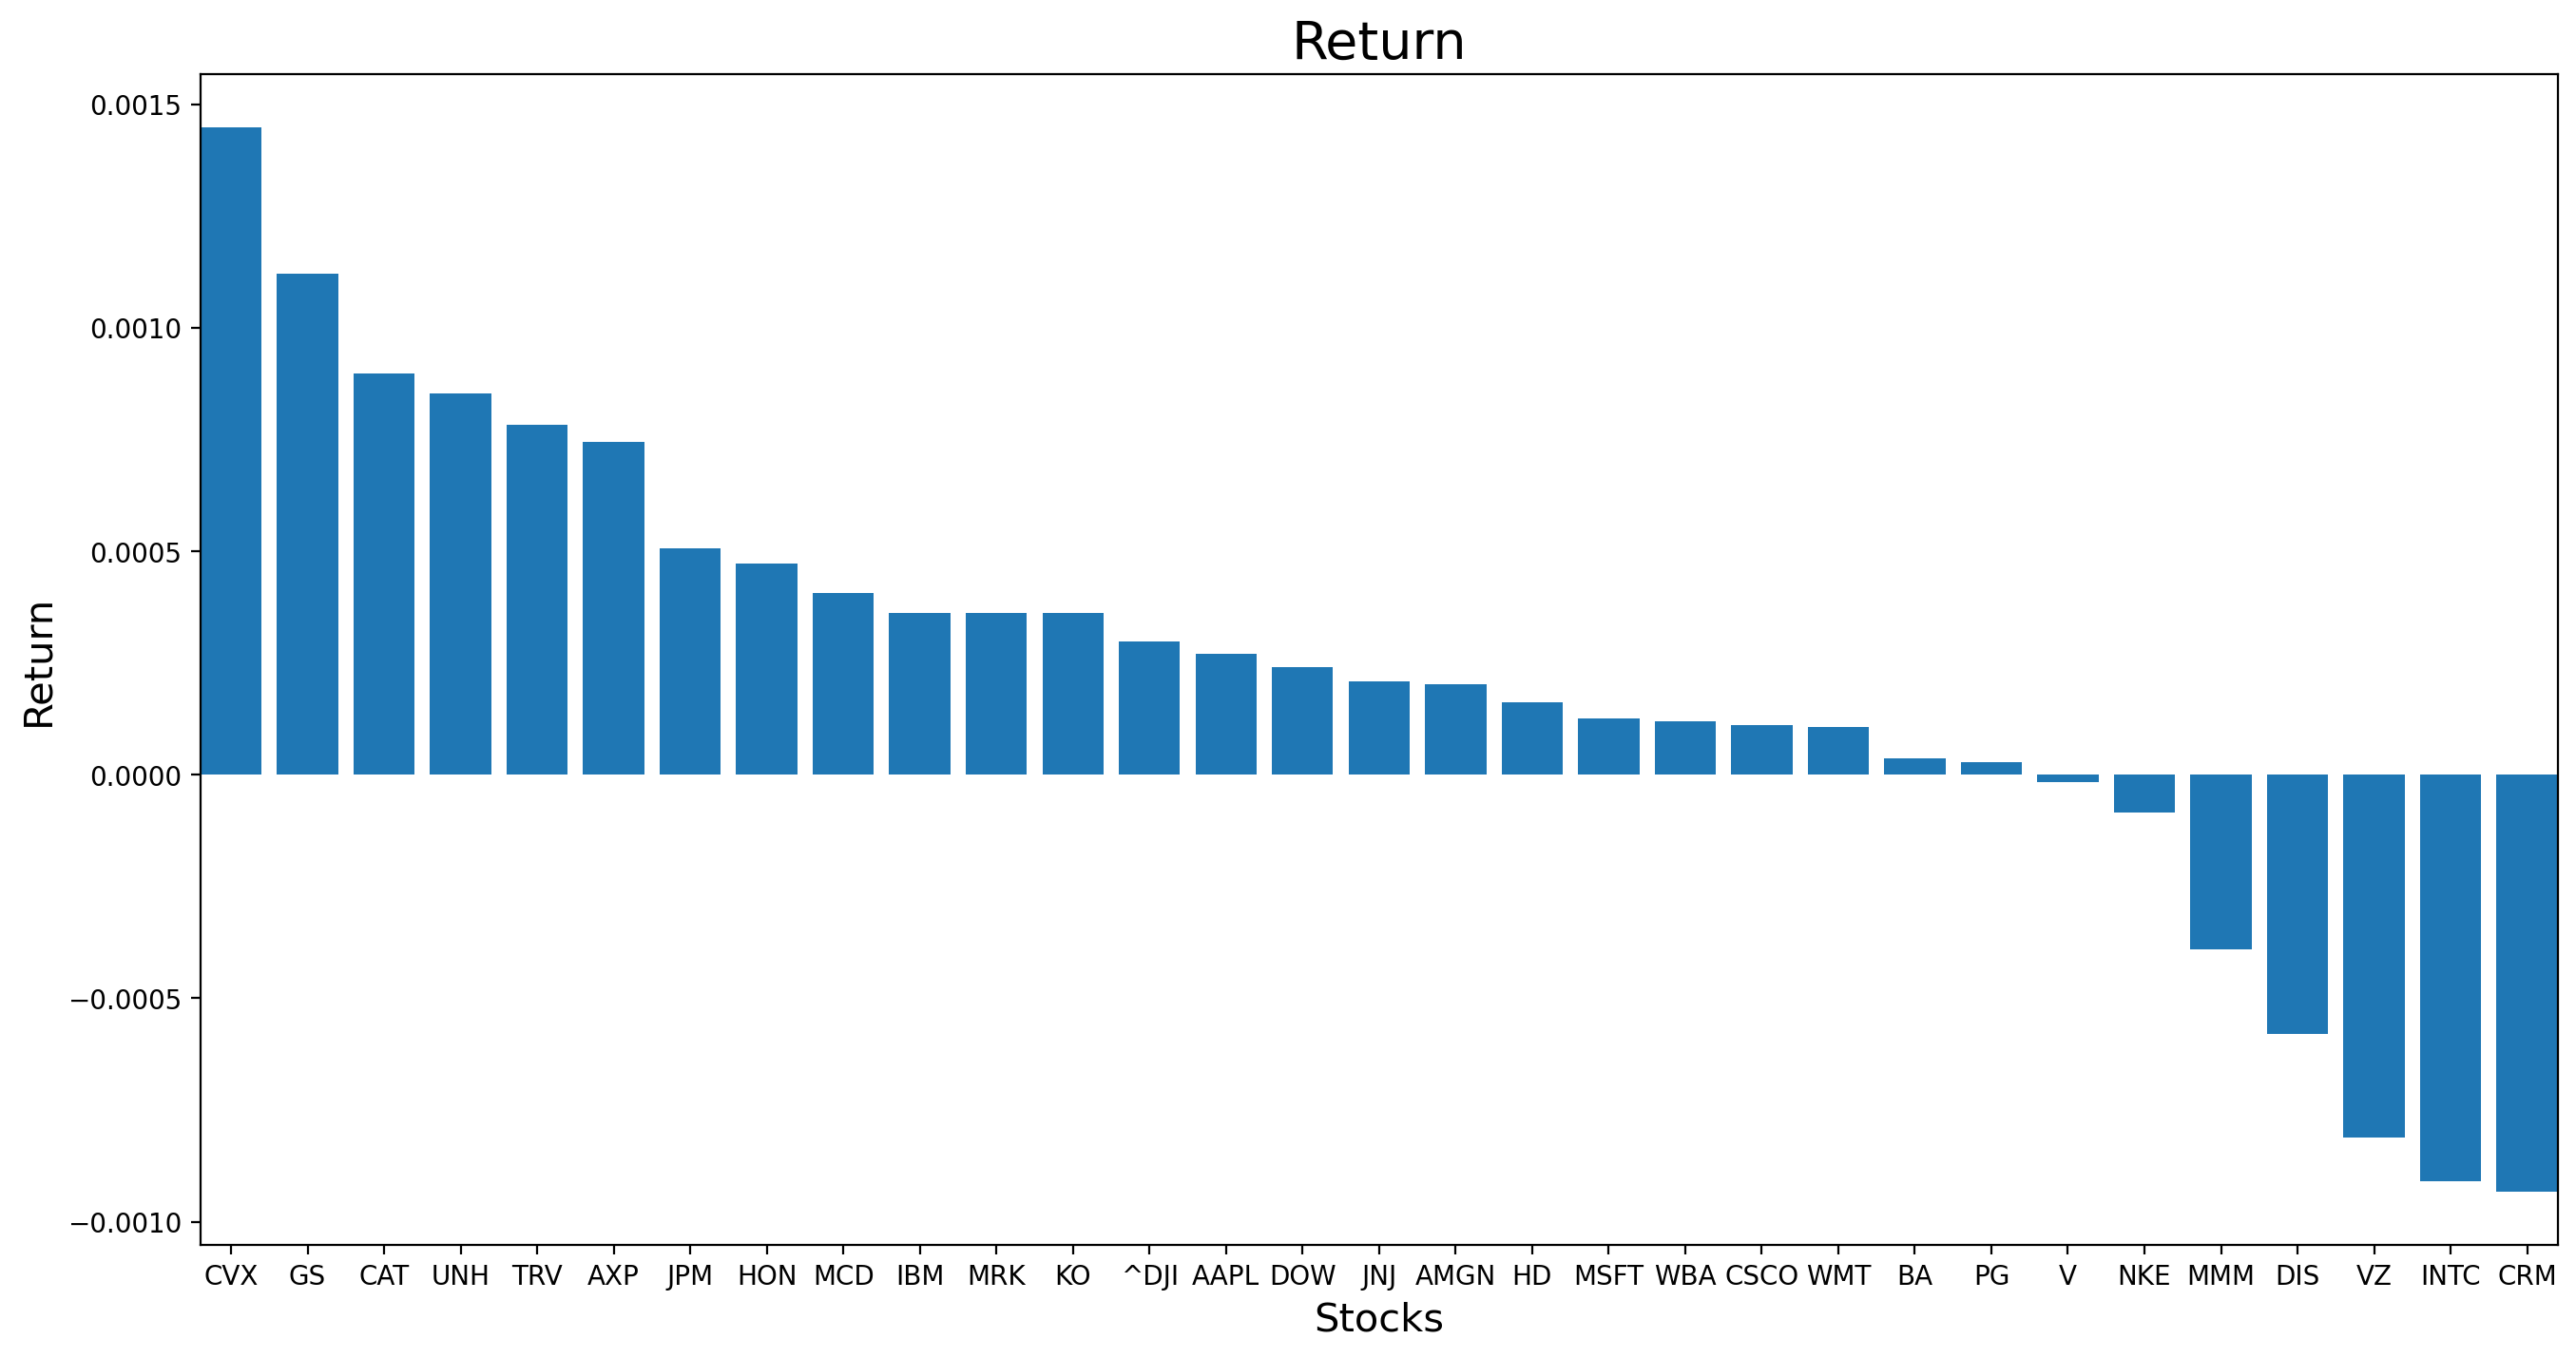

In [63]:
plt.figure(figsize = (16, 8))
plt.bar(djia_sorted_mean.index , djia_sorted_mean["mean"])
plt.title("Return", fontsize = 20)
plt.xlabel("Stocks", fontsize = 15)
plt.ylabel("Return", fontsize = 15)
plt.autoscale(enable = True, axis = "x", tight = True)
plt.show()

In [55]:
djia_sorted_std = djia_ret_summary.sort_values(by = ["std"] , ascending = False)
djia_sorted_std

,mean,std
BA,0.000037,0.027553
CRM,-0.000934,0.024185
INTC,-0.000909,0.022201
AXP,0.000746,0.021875
NKE,-0.000085,0.021464
DIS,-0.000579,0.020613
AAPL,0.000271,0.020416
WBA,0.000120,0.020048
CVX,0.001448,0.019794
DOW,0.000241,0.019667


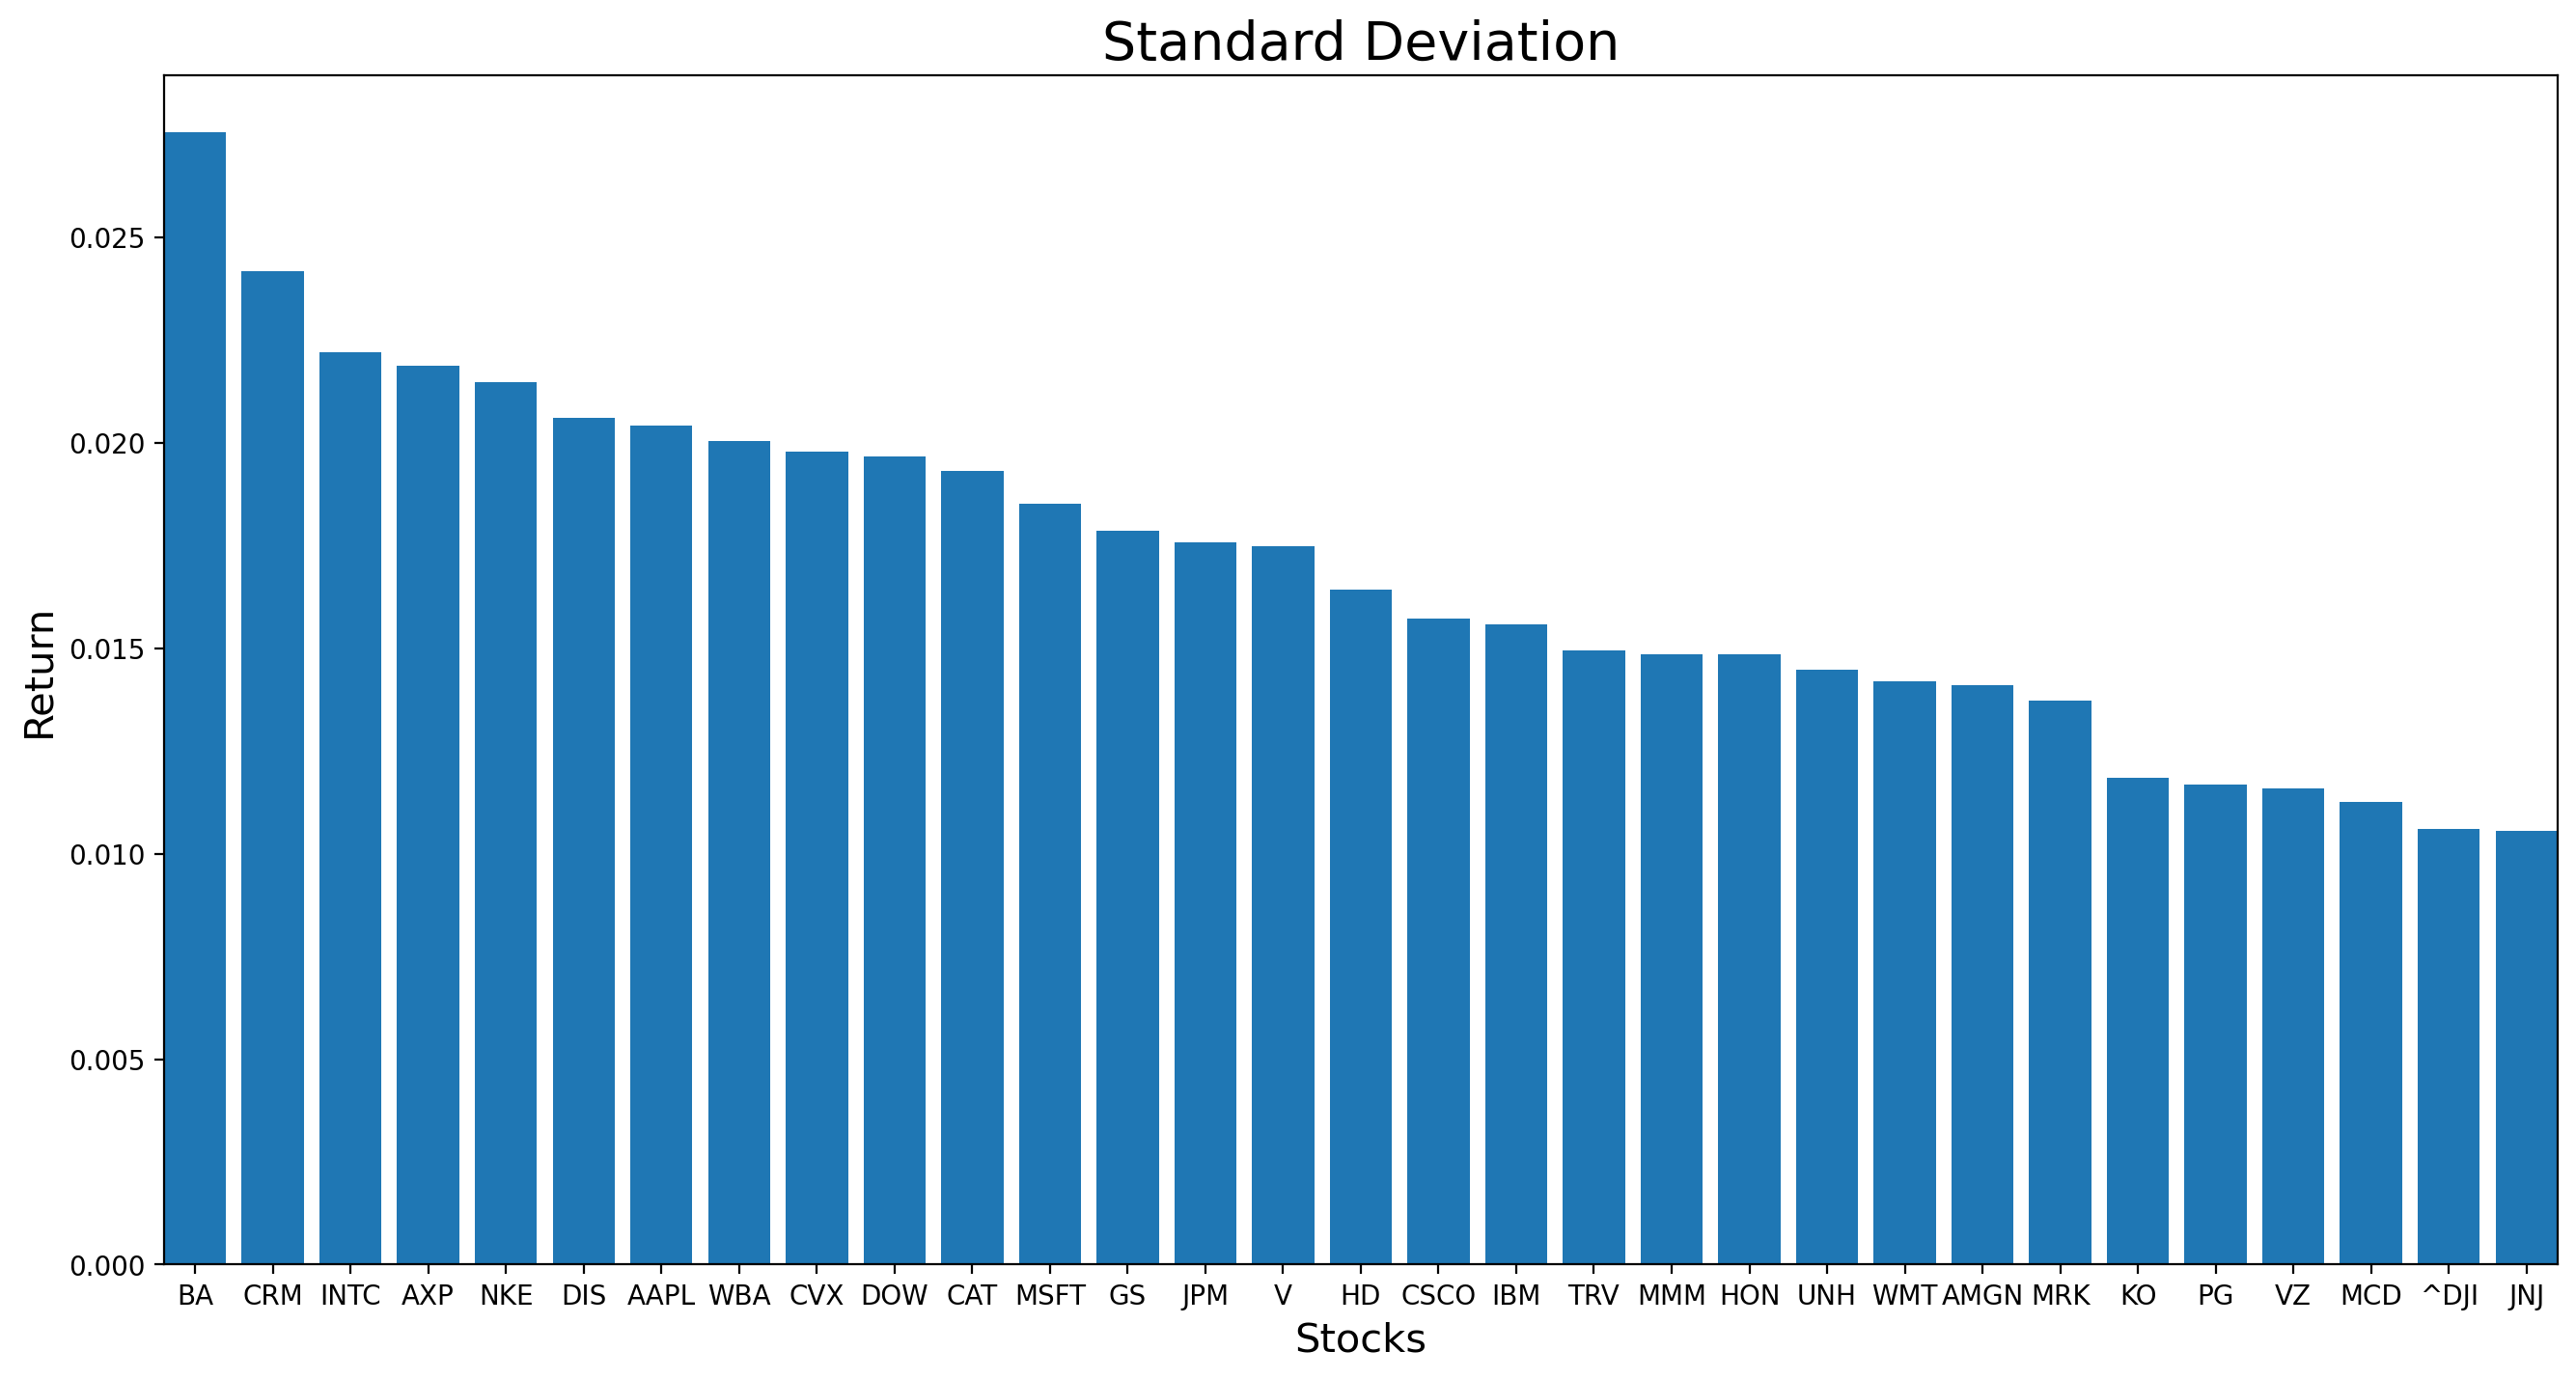

In [64]:
plt.figure(figsize = (16, 8))
plt.bar(djia_sorted_std.index , djia_sorted_std["std"])
plt.title("Standard Deviation", fontsize = 20)
plt.xlabel("Stocks", fontsize = 15)
plt.ylabel("Return", fontsize = 15)
plt.autoscale(enable = True, axis = "x", tight = True)
plt.show()

4. Compare with __Mean-Variance Analysis__ (graph)

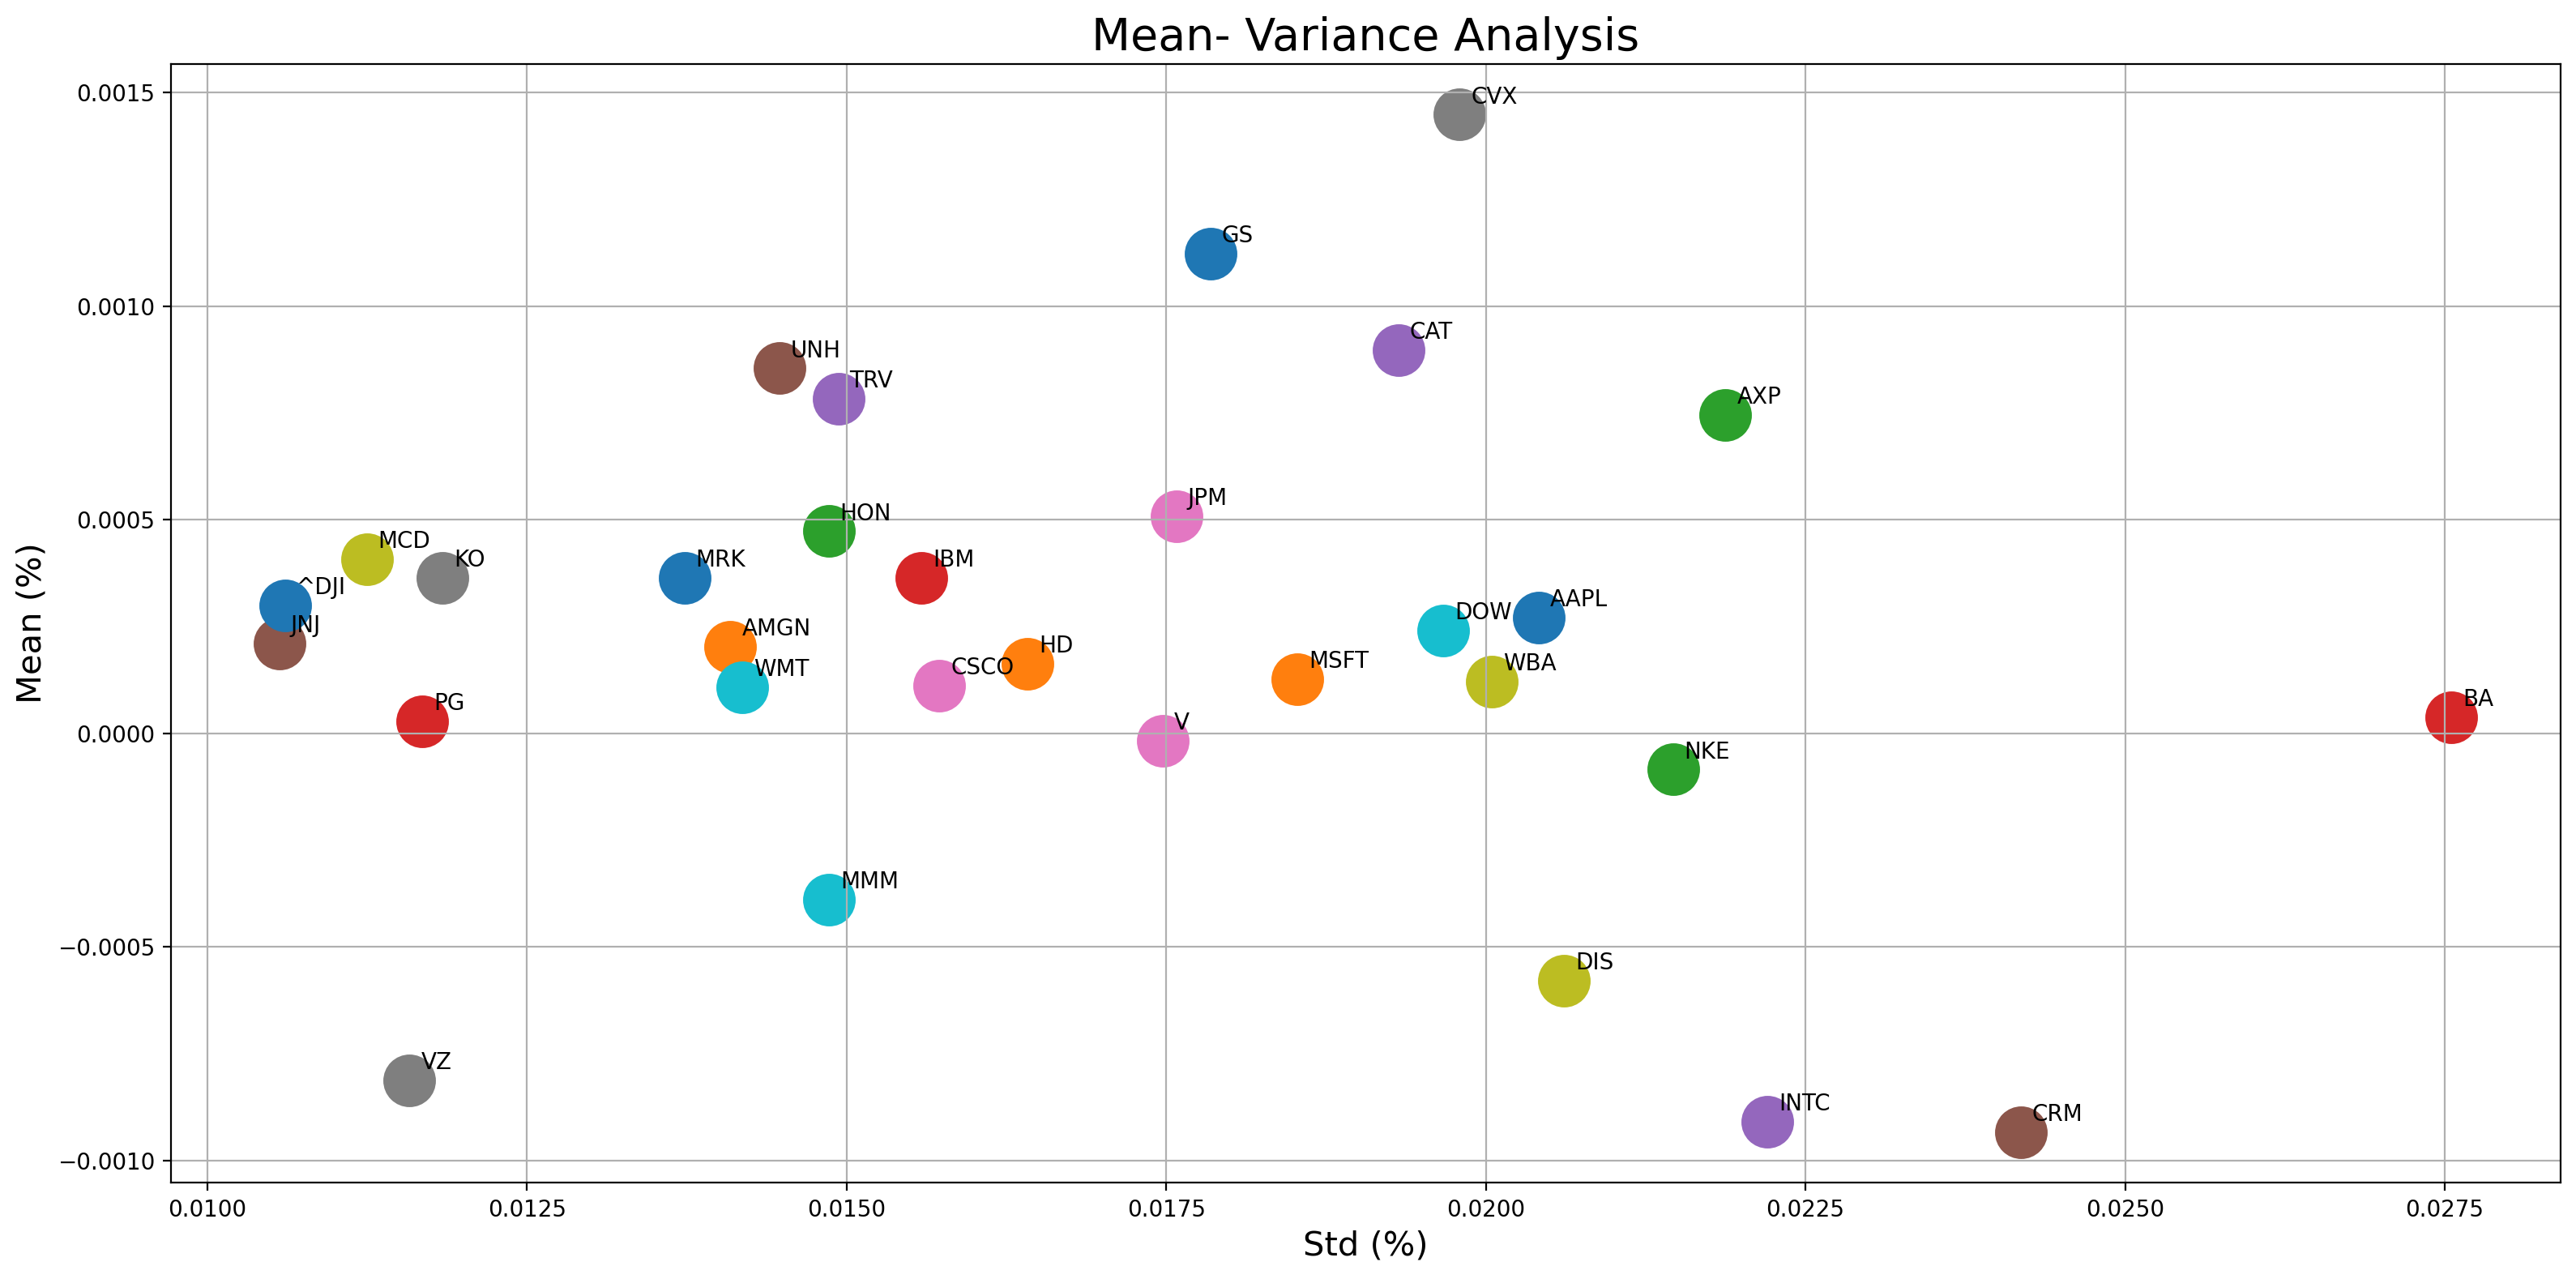

In [94]:
plt.figure(figsize = (16, 8))
for ticker in djia_ret_summary.index:
    plt.scatter(djia_ret_summary.loc[ticker , "std"] , djia_ret_summary.loc[ticker , "mean"] , s = 500)
    plt.annotate(ticker , xy = (djia_ret_summary.loc[ticker , "std"] , djia_ret_summary.loc[ticker , "mean"]) , xytext=(5, 5), textcoords = "offset points", size = 10)
plt.title("Mean- Variance Analysis", fontsize = 20)
plt.ylabel("Mean (%)", fontsize = 15)
plt.xlabel("Std (%)", fontsize = 15)
plt.tight_layout()
plt.grid()
plt.show()

In [87]:
djia_adj = pd.read_csv("DJI_Const.csv" , header = [0,1] , index_col = [0])["Adj Close"].copy()
djia_adj

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT,^DJI
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,127.289726,238.217224,98.721237,171.820007,135.369568,272.649994,39.405495,76.447708,131.869995,41.147762,...,221.623245,109.990395,130.940338,110.115639,302.914642,208.799316,53.191097,34.590927,134.576645,28430.050781
2020-09-01,132.360016,235.903885,99.576393,172.100006,138.927170,281.250000,39.228161,75.673492,133.550003,43.108482,...,223.333099,112.890297,130.798340,108.834564,303.185974,210.138840,53.092377,33.444565,143.047653,28645.660156
2020-09-02,129.617706,242.731033,101.451889,174.779999,141.990143,276.690002,39.592159,75.773689,135.389999,44.886814,...,227.637222,114.817032,133.003860,111.482124,310.367523,213.221756,54.321861,33.817589,143.134857,29100.500000
2020-09-03,119.240417,233.129745,101.510201,168.770004,139.602539,265.010010,38.220158,74.944817,133.240005,44.129879,...,213.535797,110.934090,130.874084,109.460876,306.481201,205.814941,54.393661,33.744808,140.091492,28292.730469
2020-09-04,119.319313,233.590546,102.686020,171.050003,140.953293,254.699997,38.098816,74.626007,131.990005,44.321396,...,210.538651,110.491737,130.590103,110.618584,302.381622,201.579651,54.276993,33.562840,138.434143,28133.310547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,134.869995,289.649994,145.860001,168.740005,225.539993,142.059998,43.910000,177.929993,86.750000,47.680000,...,224.509995,92.099998,136.479996,182.149994,540.659973,193.929993,37.619999,36.460838,139.470001,32513.939453
2022-11-10,146.869995,291.010010,154.750000,177.580002,232.449997,156.300003,45.660000,181.300003,90.459999,49.959999,...,242.979996,99.489998,141.179993,183.300003,544.169983,205.570007,38.520000,38.042229,142.360001,33715.371094
2022-11-11,149.699997,285.019989,154.889999,177.490005,236.490005,157.729996,44.790001,186.460007,95.010002,53.139999,...,247.110001,106.089996,140.970001,181.729996,522.080017,205.000000,38.299999,40.779999,142.580002,33747.859375


In [88]:
djia_adj_ret = np.log(djia_adj).diff()
djia_adj_ret

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT,^DJI
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,0.039060,-0.009759,0.008625,0.001628,0.025941,0.031055,-0.004510,-0.010179,0.012659,0.046550,...,0.007686,0.026023,-0.001085,-0.011702,0.000895,0.006395,-0.001858,-0.033702,0.061044,0.007555
2020-09-02,-0.020936,0.028530,0.018660,0.015452,0.021808,-0.016346,0.009236,0.001323,0.013684,0.040424,...,0.019089,0.016923,0.016721,0.024035,0.023411,0.014564,0.022893,0.011092,0.000609,0.015753
2020-09-03,-0.083448,-0.040359,0.000575,-0.034991,-0.016958,-0.043130,-0.035268,-0.010999,-0.016007,-0.017007,...,-0.063949,-0.034404,-0.016142,-0.018297,-0.012601,-0.035355,0.001321,-0.002154,-0.021492,-0.028150
2020-09-04,0.000661,0.001975,0.011517,0.013419,0.009629,-0.039681,-0.003180,-0.004263,-0.009426,0.004330,...,-0.014135,-0.003995,-0.002172,0.010521,-0.013467,-0.020793,-0.002147,-0.005407,-0.011901,-0.005651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,-0.033753,-0.009415,-0.029320,-0.005202,-0.018755,-0.034863,-0.015816,-0.040802,-0.141139,-0.040486,...,-0.019234,-0.017757,-0.002415,-0.014985,-0.022658,-0.037448,-0.006623,-0.037248,-0.023525,-0.019700
2022-11-10,0.085236,0.004684,0.059164,0.051062,0.030178,0.095528,0.039081,0.018763,0.041877,0.046711,...,0.079059,0.077182,0.033858,0.006294,0.006471,0.058289,0.023642,0.042458,0.020510,0.036285
2022-11-11,0.019085,-0.020798,0.000904,-0.000507,0.017231,0.009107,-0.019238,0.028064,0.049074,0.061707,...,0.016854,0.064231,-0.001489,-0.008602,-0.041441,-0.002777,-0.005728,0.069495,0.001544,0.000963


In [89]:
adj_ret_summary = djia_adj_ret.agg(["mean", "std"]).T
adj_ret_summary

,mean,std
AAPL,0.000295,0.020415
AMGN,0.000313,0.014064
AXP,0.000797,0.021891
BA,0.000037,0.027553
CAT,0.000987,0.019311
CRM,-0.000934,0.024185
CSCO,0.000234,0.015683
CVX,0.001616,0.019662
DIS,-0.000579,0.020613
DOW,0.000406,0.019591


### -------------SOLUTION---------------

__Data Import__

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("DJI_Const.csv", header = [0, 1], index_col = 0, parse_dates=[0])
df

In [ ]:
close = df["Close"] # for Price Returns
close

In [ ]:
#close = df["Adj Close"] # for Total Returns
#close

__Log Returns__

In [ ]:
returns = np.log(close / close.shift()).dropna()
returns

__Mean and Std__

In [ ]:
summary = returns.agg(["mean", "std"]).T
summary

In [ ]:
summary.columns = ["Mean", "Std"]
summary

__Highest/Lowest Return__

In [ ]:
summary.sort_values("Mean", ascending= False, inplace = True)
summary

In [ ]:
fig = plt.figure(figsize = (12, 8))
plt.bar(summary.index, summary.Mean)
plt.title("Return", fontsize = 15)
fig.autofmt_xdate()
plt.show()

__Highest/Lowest Risk__

In [ ]:
summary.sort_values("Std", ascending= True, inplace = True)
summary

In [ ]:
fig = plt.figure(figsize = (12, 8))
plt.bar(summary.index, summary.Std)
plt.title("Risk", fontsize = 15)
fig.autofmt_xdate()
plt.show()

__Mean-Variance Analysis__

In [ ]:
summary.plot(kind = "scatter", x = "Std", y = "Mean", figsize = (15,12), s = 50, fontsize = 15)
for i in summary.index:
    plt.annotate(i, xy=(summary.loc[i, "Std"]+0.00002, summary.loc[i, "Mean"]+0.00002), size = 12)
plt.xlabel("Risk (std)", fontsize = 15)
plt.ylabel("Mean Return", fontsize = 15)
plt.title("Mean-Variance Analysis", fontsize = 20)
plt.show()

__DJI__:
- Return seems to be (approx.) the weighted average of its constituents
- Risk seems to be much lower than the weighted average of its constituents -> __Diversification Effect!!!__